# EDA Graficos Bronze - Modulo 2 LRFMV

Notebook de graficos para validar calidad, cobertura y comportamiento inicial de las fuentes Bronze del Modulo 2.

Este EDA se mantiene en Bronze: no calcula score LRFMV final, K-Means ni churn. Los graficos sirven para sustentar las decisiones de entrada descritas en `M2_SPEC.md`, especialmente el uso de `first_purchase_date` transaccional para la antiguedad comercial.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

PALETTE = "crest"

## Carga de datos Bronze

In [3]:
def find_data_dir() -> Path:
    candidates = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend(
            [
                base / "data" / "raw",
                base / "modules" / "m2_lrfmv" / "data" / "raw",
                base / "bebidas-ds-project" / "modules" / "m2_lrfmv" / "data" / "raw",
            ]
        )

    for candidate in candidates:
        if (candidate / "clients_raw.csv").exists():
            return candidate.resolve()

    raise FileNotFoundError("No se encontro data/raw con clients_raw.csv")


DATA_DIR = find_data_dir()
DATA_DIR

WindowsPath('E:/proyecto_2026/2026-II/project_bebidas/bebidas-ds-project/modules/m2_lrfmv/data/raw')

In [4]:
clients = pd.read_csv(DATA_DIR / "clients_raw.csv", parse_dates=["registration_date"])
transactions = pd.read_csv(DATA_DIR / "transactions_raw.csv", parse_dates=["date"])
ground_truth = pd.read_csv(DATA_DIR / "_ground_truth.csv")

snapshot_date = transactions["date"].max()
date_min = transactions["date"].min()

print(f"Clientes: {len(clients):,}")
print(f"Transacciones: {len(transactions):,}")
print(f"Ground truth: {len(ground_truth):,}")
print(f"Rango transaccional: {date_min.date()} a {snapshot_date.date()}")

Clientes: 500
Transacciones: 68,483
Ground truth: 500
Rango transaccional: 2021-01-01 a 2025-06-30


In [5]:
assert len(clients) == 500
assert len(transactions) == 68483
assert transactions["client_id"].nunique() == 498
assert str(date_min.date()) == "2021-01-01"
assert str(snapshot_date.date()) == "2025-06-30"

print("Validaciones Bronze OK")

Validaciones Bronze OK


## Preparacion exploratoria

Las variables agregadas se usan solo para graficar y validar Bronze. No se persisten salidas.

In [6]:
client_tx = (
    transactions.groupby("client_id")
    .agg(
        first_purchase_date=("date", "min"),
        last_purchase_date=("date", "max"),
        n_transactions=("transaction_id", "count"),
        monetary_total=("amount", "sum"),
        monetary_avg=("amount", "mean"),
        sku_total=("sku_count", "sum"),
        sku_avg=("sku_count", "mean"),
    )
    .reset_index()
)

clients_eda = clients.merge(client_tx, on="client_id", how="left")
clients_eda["has_transactions"] = clients_eda["n_transactions"].notna()
clients_eda["days_since_first_purchase"] = (snapshot_date - clients_eda["first_purchase_date"]).dt.days
clients_eda["days_since_last_purchase"] = (snapshot_date - clients_eda["last_purchase_date"]).dt.days
clients_eda["first_purchase_before_registration"] = (
    clients_eda["first_purchase_date"].notna()
    & (clients_eda["first_purchase_date"] < clients_eda["registration_date"])
)
clients_eda["purchase_registration_gap_days"] = (
    clients_eda["first_purchase_date"] - clients_eda["registration_date"]
).dt.days

transactions_eda = transactions.merge(
    clients[["client_id", "store_type", "zone"]], on="client_id", how="left"
)
transactions_eda["month"] = transactions_eda["date"].dt.to_period("M").dt.to_timestamp()

monthly_activity = (
    transactions_eda.groupby("month")
    .agg(transactions=("transaction_id", "count"), amount_total=("amount", "sum"))
    .reset_index()
)

## Cobertura Bronze

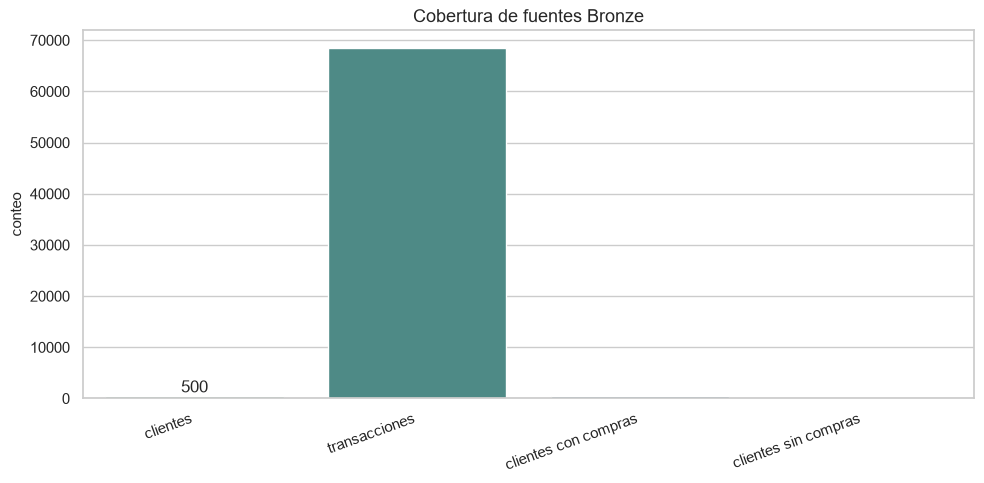

In [7]:
coverage = pd.DataFrame(
    {
        "metric": ["clientes", "transacciones", "clientes con compras", "clientes sin compras"],
        "count": [
            len(clients),
            len(transactions),
            int(clients_eda["has_transactions"].sum()),
            int((~clients_eda["has_transactions"]).sum()),
        ],
    }
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=coverage, x="metric", y="count", hue="metric", palette=PALETTE, legend=False, ax=ax)
ax.set_title("Cobertura de fuentes Bronze")
ax.set_xlabel("")
ax.set_ylabel("conteo")
ax.bar_label(ax.containers[0], fmt="{:,.0f}")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

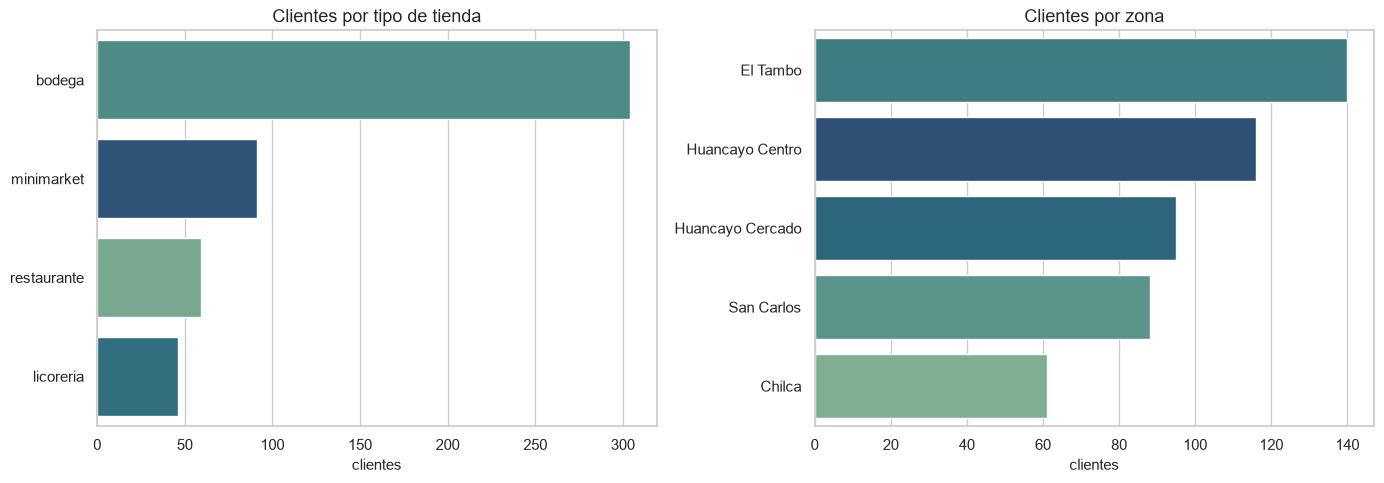

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=clients, y="store_type", order=clients["store_type"].value_counts().index, ax=axes[0], hue="store_type", palette=PALETTE, legend=False)
axes[0].set_title("Clientes por tipo de tienda")
axes[0].set_xlabel("clientes")
axes[0].set_ylabel("")

sns.countplot(data=clients, y="zone", order=clients["zone"].value_counts().index, ax=axes[1], hue="zone", palette=PALETTE, legend=False)
axes[1].set_title("Clientes por zona")
axes[1].set_xlabel("clientes")
axes[1].set_ylabel("")

plt.tight_layout()

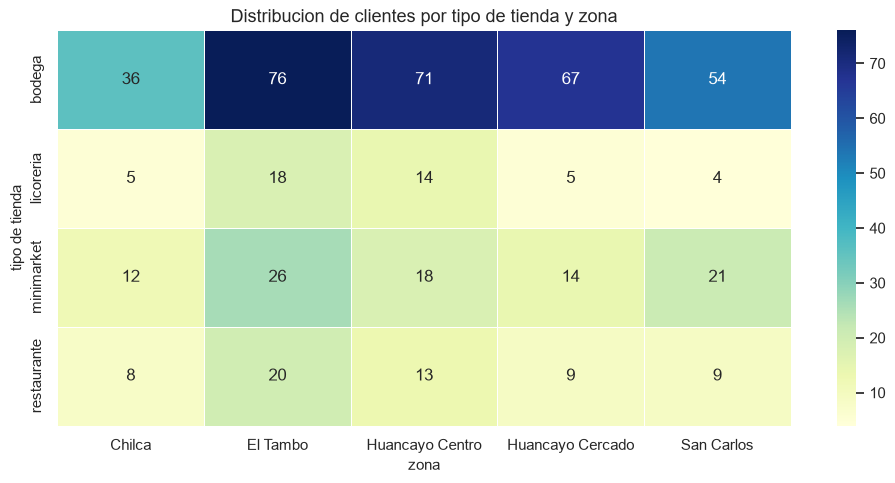

In [9]:
store_zone = pd.crosstab(clients["store_type"], clients["zone"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(store_zone, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Distribucion de clientes por tipo de tienda y zona")
ax.set_xlabel("zona")
ax.set_ylabel("tipo de tienda")
plt.tight_layout()

## Actividad transaccional

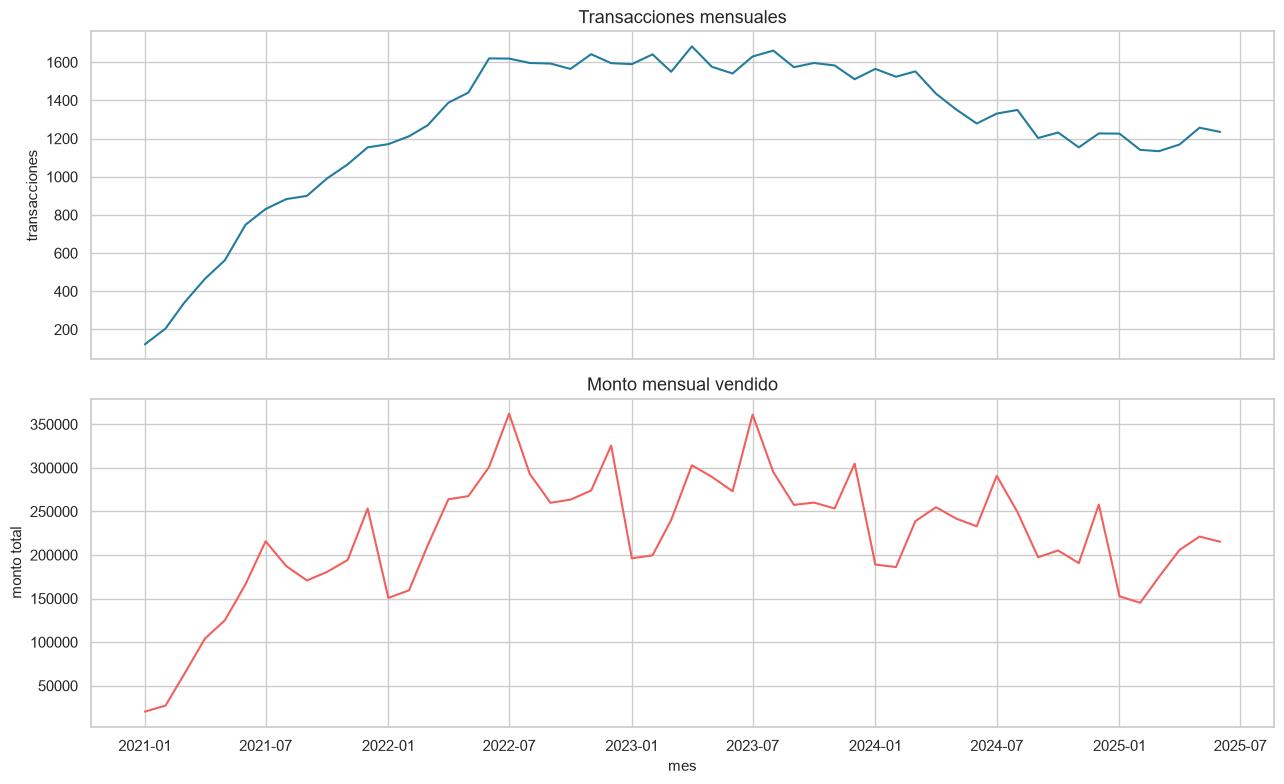

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

sns.lineplot(data=monthly_activity, x="month", y="transactions", ax=axes[0], color="#227C9D")
axes[0].set_title("Transacciones mensuales")
axes[0].set_xlabel("")
axes[0].set_ylabel("transacciones")

sns.lineplot(data=monthly_activity, x="month", y="amount_total", ax=axes[1], color="#F25F5C")
axes[1].set_title("Monto mensual vendido")
axes[1].set_xlabel("mes")
axes[1].set_ylabel("monto total")

plt.tight_layout()

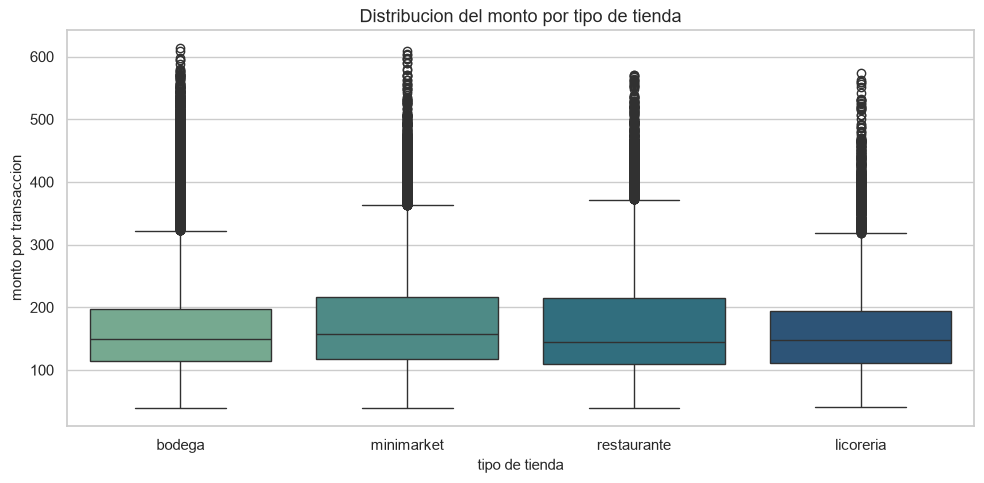

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=transactions_eda, x="store_type", y="amount", hue="store_type", palette=PALETTE, legend=False, ax=ax)
ax.set_title("Distribucion del monto por tipo de tienda")
ax.set_xlabel("tipo de tienda")
ax.set_ylabel("monto por transaccion")
plt.tight_layout()

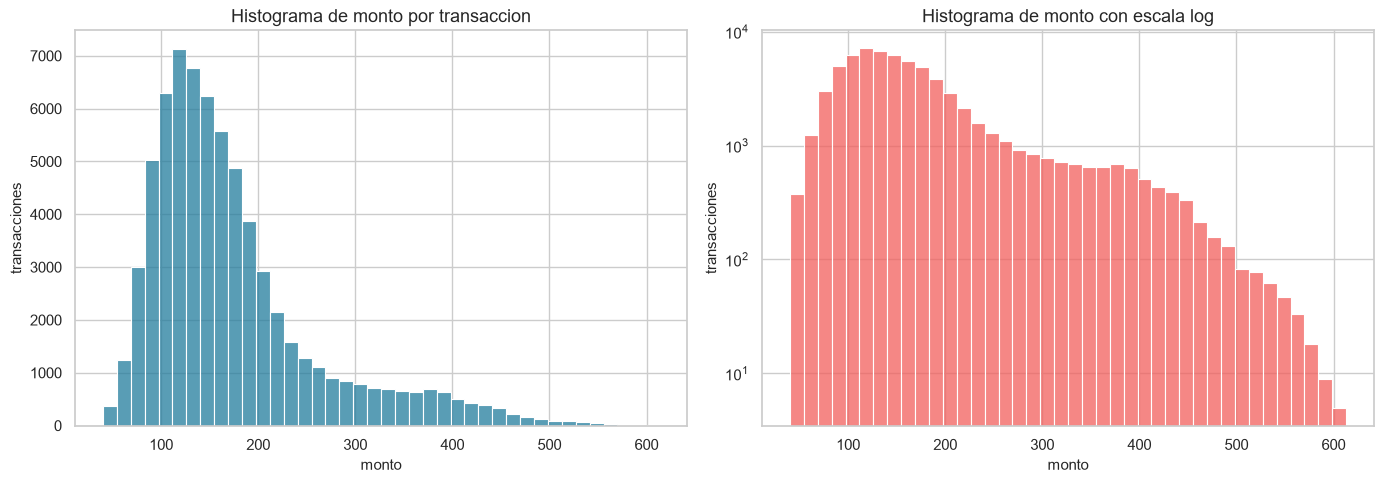

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=transactions_eda, x="amount", bins=40, ax=axes[0], color="#227C9D")
axes[0].set_title("Histograma de monto por transaccion")
axes[0].set_xlabel("monto")
axes[0].set_ylabel("transacciones")

sns.histplot(data=transactions_eda, x="amount", bins=40, ax=axes[1], color="#F25F5C")
axes[1].set_title("Histograma de monto con escala log")
axes[1].set_xlabel("monto")
axes[1].set_ylabel("transacciones")
axes[1].set_yscale("log")

plt.tight_layout()

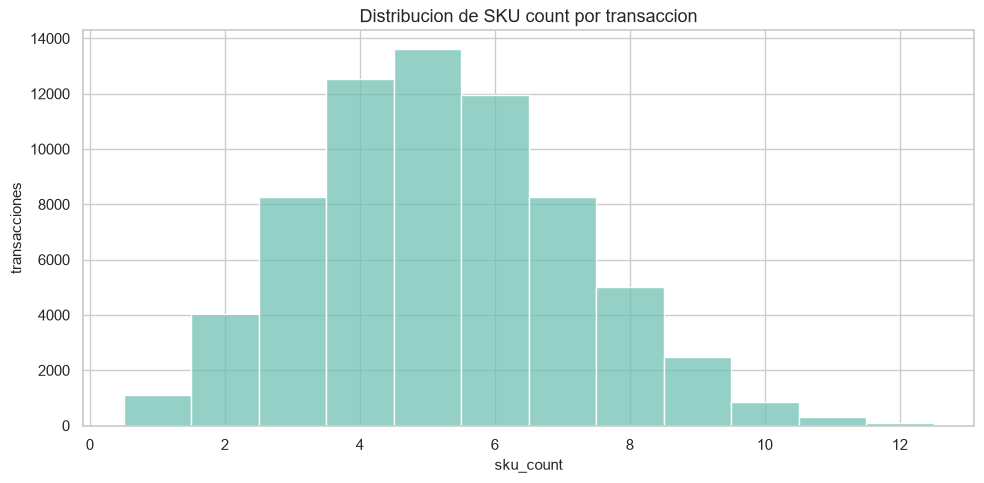

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=transactions_eda, x="sku_count", discrete=True, color="#70C1B3", ax=ax)
ax.set_title("Distribucion de SKU count por transaccion")
ax.set_xlabel("sku_count")
ax.set_ylabel("transacciones")
plt.tight_layout()

## Consistencia para LRFMV

La antiguedad comercial para LRFMV debe salir de `first_purchase_date`, no de `registration_date`, porque hay clientes cuya primera compra ocurre antes del registro en el maestro.

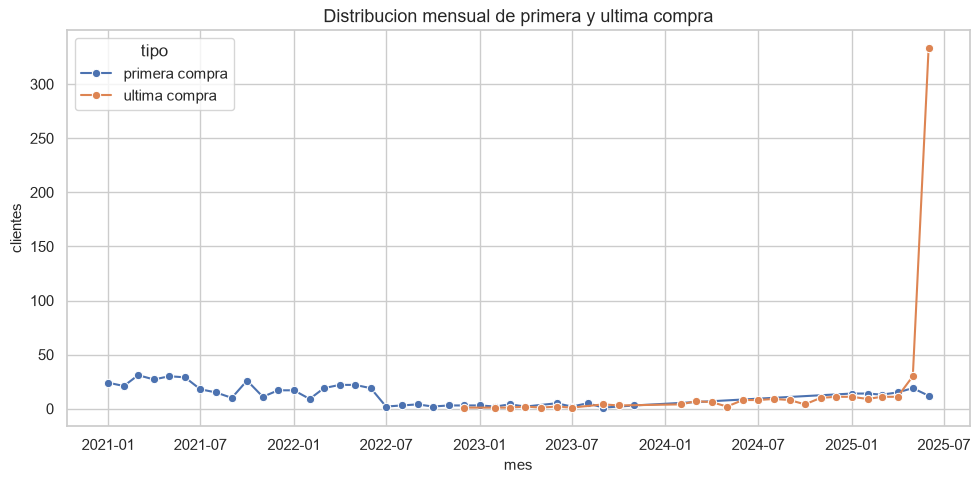

In [14]:
purchase_dates_long = pd.concat(
    [
        clients_eda[["first_purchase_date"]].rename(columns={"first_purchase_date": "purchase_date"}).assign(tipo="primera compra"),
        clients_eda[["last_purchase_date"]].rename(columns={"last_purchase_date": "purchase_date"}).assign(tipo="ultima compra"),
    ],
    ignore_index=True,
).dropna()
purchase_dates_long["month"] = purchase_dates_long["purchase_date"].dt.to_period("M").dt.to_timestamp()

purchase_dates_monthly = purchase_dates_long.groupby(["month", "tipo"]).size().reset_index(name="clientes")

ax = sns.lineplot(data=purchase_dates_monthly, x="month", y="clientes", hue="tipo", marker="o")
ax.set_title("Distribucion mensual de primera y ultima compra")
ax.set_xlabel("mes")
ax.set_ylabel("clientes")
plt.tight_layout()

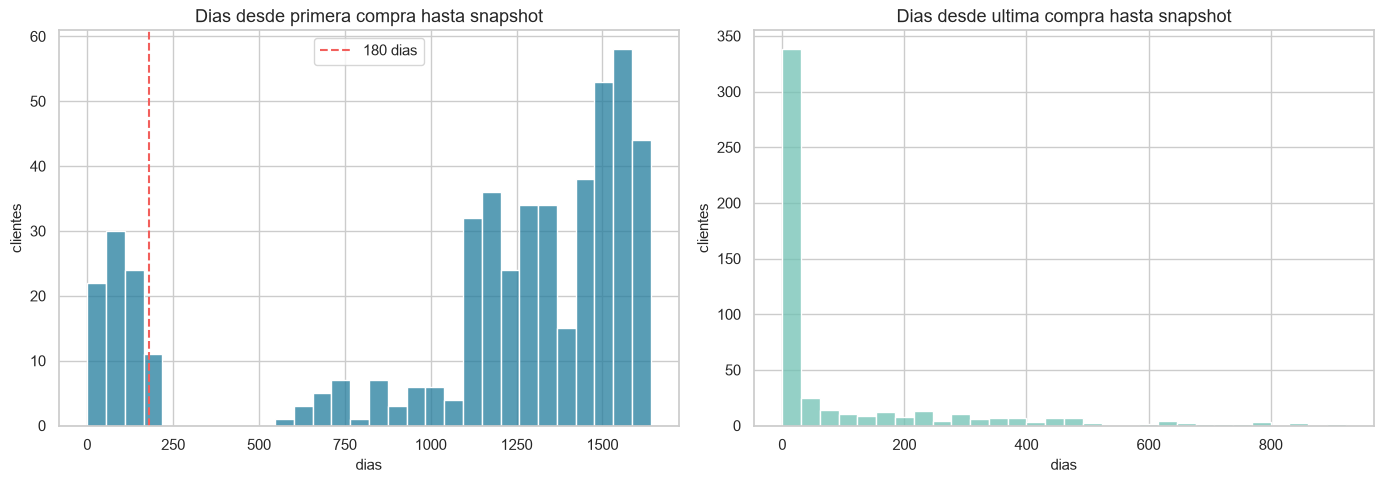

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=clients_eda, x="days_since_first_purchase", bins=30, ax=axes[0], color="#227C9D")
axes[0].axvline(180, color="#F25F5C", linestyle="--", label="180 dias")
axes[0].set_title("Dias desde primera compra hasta snapshot")
axes[0].set_xlabel("dias")
axes[0].set_ylabel("clientes")
axes[0].legend()

sns.histplot(data=clients_eda, x="days_since_last_purchase", bins=30, ax=axes[1], color="#70C1B3")
axes[1].set_title("Dias desde ultima compra hasta snapshot")
axes[1].set_xlabel("dias")
axes[1].set_ylabel("clientes")

plt.tight_layout()

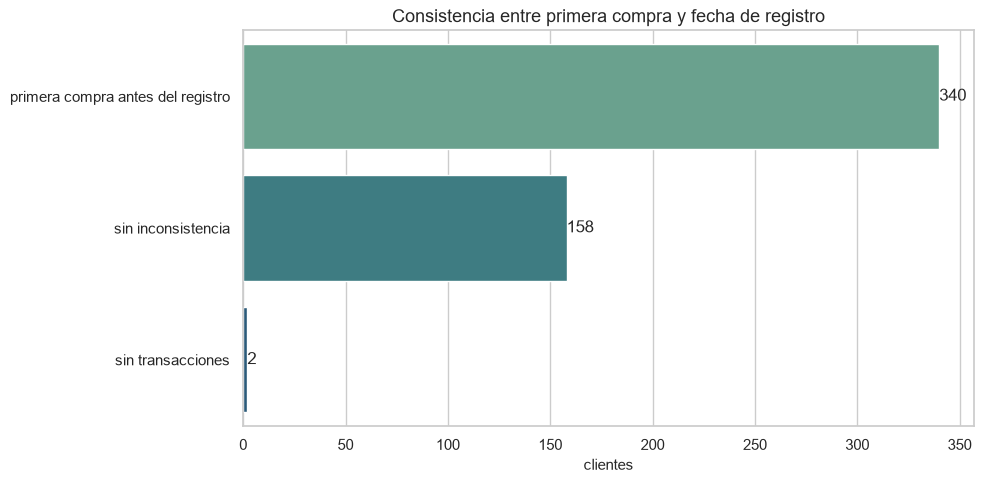

In [16]:
registration_status = clients_eda.assign(
    status=lambda df: df["first_purchase_before_registration"].map(
        {True: "primera compra antes del registro", False: "sin inconsistencia"}
    )
)
registration_status.loc[~registration_status["has_transactions"], "status"] = "sin transacciones"

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(
    data=registration_status,
    y="status",
    order=registration_status["status"].value_counts().index,
    hue="status",
    palette=PALETTE,
    legend=False,
    ax=ax,
)
ax.set_title("Consistencia entre primera compra y fecha de registro")
ax.set_xlabel("clientes")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")
plt.tight_layout()

Clientes con primera compra antes del registro: 340


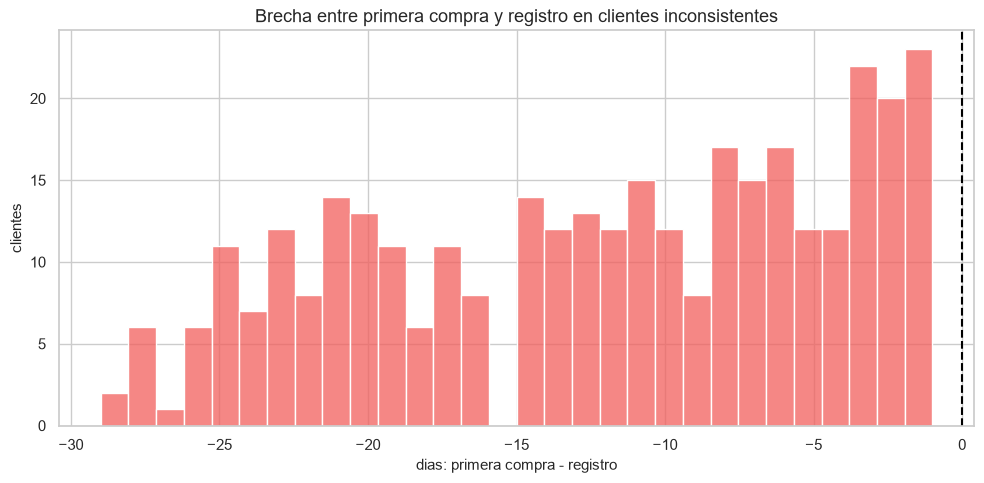

In [17]:
inconsistent_clients = clients_eda.loc[clients_eda["first_purchase_before_registration"]].copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=inconsistent_clients, x="purchase_registration_gap_days", bins=30, color="#F25F5C", ax=ax)
ax.axvline(0, color="black", linestyle="--")
ax.set_title("Brecha entre primera compra y registro en clientes inconsistentes")
ax.set_xlabel("dias: primera compra - registro")
ax.set_ylabel("clientes")
plt.tight_layout()

print(f"Clientes con primera compra antes del registro: {len(inconsistent_clients):,}")

## Ground truth sintetico

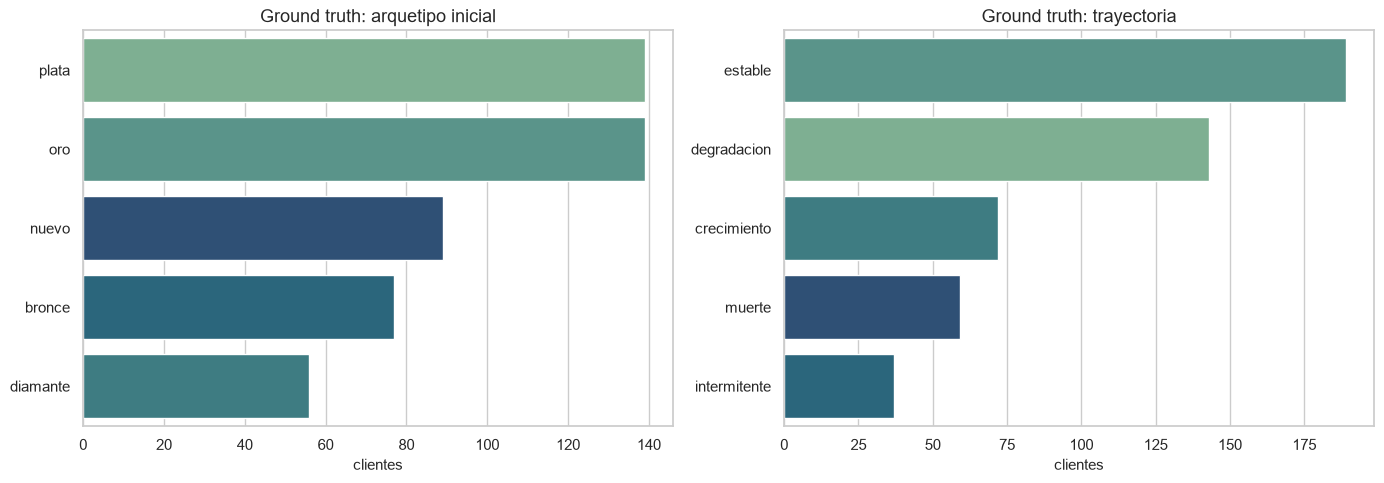

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=ground_truth,
    y="archetype_initial",
    order=ground_truth["archetype_initial"].value_counts().index,
    ax=axes[0],
    hue="archetype_initial",
    palette=PALETTE,
    legend=False,
)
axes[0].set_title("Ground truth: arquetipo inicial")
axes[0].set_xlabel("clientes")
axes[0].set_ylabel("")

sns.countplot(
    data=ground_truth,
    y="trajectory_type",
    order=ground_truth["trajectory_type"].value_counts().index,
    ax=axes[1],
    hue="trajectory_type",
    palette=PALETTE,
    legend=False,
)
axes[1].set_title("Ground truth: trayectoria")
axes[1].set_xlabel("clientes")
axes[1].set_ylabel("")

plt.tight_layout()

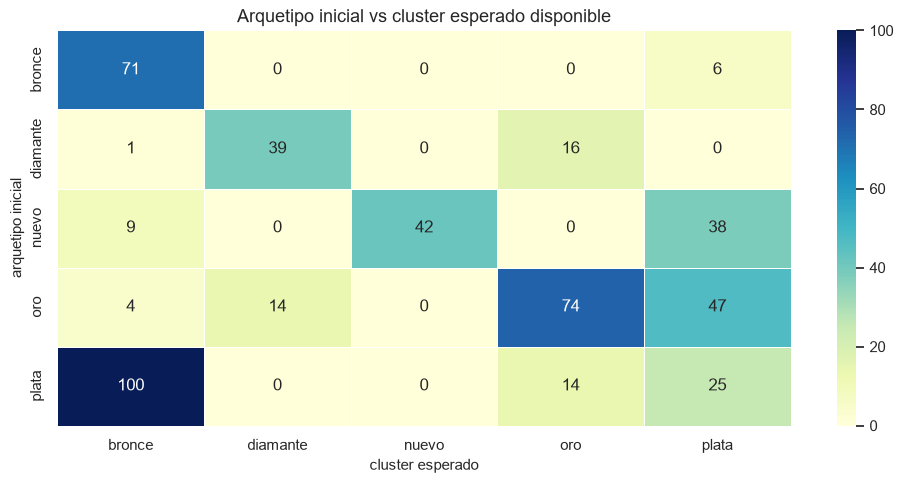

In [19]:
ground_truth_plot = ground_truth.copy()
ground_truth_plot["expected_cluster_for_plot"] = ground_truth_plot["expected_cluster_jun2025"].fillna(
    ground_truth_plot["expected_cluster_tentative"]
)

archetype_cluster = pd.crosstab(
    ground_truth_plot["archetype_initial"], ground_truth_plot["expected_cluster_for_plot"]
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(archetype_cluster, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Arquetipo inicial vs cluster esperado disponible")
ax.set_xlabel("cluster esperado")
ax.set_ylabel("arquetipo inicial")
plt.tight_layout()

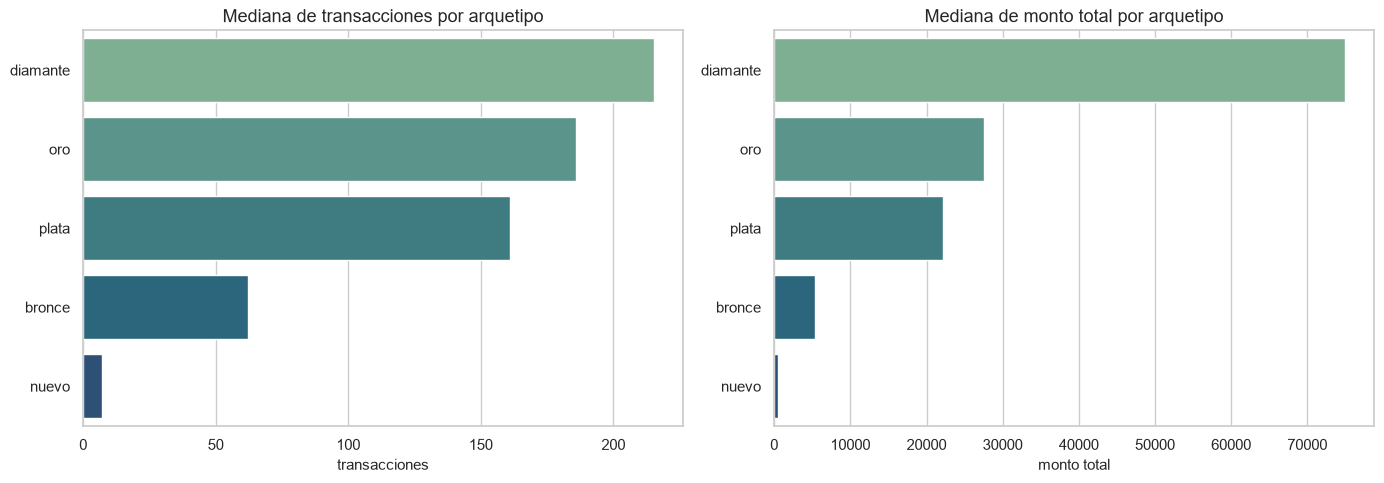

In [20]:
ground_truth_behavior = (
    ground_truth[["client_id", "archetype_initial", "trajectory_type"]]
    .merge(client_tx, on="client_id", how="left")
    .assign(n_transactions=lambda df: df["n_transactions"].fillna(0), monetary_total=lambda df: df["monetary_total"].fillna(0))
)

behavior_summary = (
    ground_truth_behavior.groupby("archetype_initial", as_index=False)
    .agg(
        median_transactions=("n_transactions", "median"),
        median_monetary=("monetary_total", "median"),
    )
    .sort_values("median_monetary", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=behavior_summary, y="archetype_initial", x="median_transactions", ax=axes[0], hue="archetype_initial", palette=PALETTE, legend=False)
axes[0].set_title("Mediana de transacciones por arquetipo")
axes[0].set_xlabel("transacciones")
axes[0].set_ylabel("")

sns.barplot(data=behavior_summary, y="archetype_initial", x="median_monetary", ax=axes[1], hue="archetype_initial", palette=PALETTE, legend=False)
axes[1].set_title("Mediana de monto total por arquetipo")
axes[1].set_xlabel("monto total")
axes[1].set_ylabel("")

plt.tight_layout()

## Cierre

Este notebook deja evidencia visual para la capa Bronze. Las decisiones metodologicas posteriores del Modulo 2 quedan fuera de alcance aqui y deben implementarse en notebooks o pipeline de features, normalizacion, scoring, clustering y churn.